# Titanic Spaceship Kaggle Competition 


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report, accuracy_score, f1_score


In [2]:
dataset=pd.read_csv(r"/kaggle/input/spaceship-titanic/train.csv")
dataset.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
test=pd.read_csv(r"/kaggle/input/spaceship-titanic/test.csv")
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [5]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


In [6]:
data=dataset.iloc[:,[2,3,5,6,7,10,11,13]]
data

,CryoSleep,Cabin,Age,VIP,RoomService,Spa,VRDeck,Transported
0,False,B/0/P,39.0,False,0.0,0.0,0.0,False
1,False,F/0/S,24.0,False,109.0,549.0,44.0,True
2,False,A/0/S,58.0,True,43.0,6715.0,49.0,False
3,False,A/0/S,33.0,False,0.0,3329.0,193.0,False
4,False,F/1/S,16.0,False,303.0,565.0,2.0,True
...,...,...,...,...,...,...,...,...
8688,False,A/98/P,41.0,True,0.0,1643.0,74.0,False
8689,True,G/1499/S,18.0,False,0.0,0.0,0.0,False
8690,False,G/1500/S,26.0,False,0.0,1.0,0.0,True
8691,False,E/608/S,32.0,False,0.0,353.0,3235.0,False


In [7]:
pd.options.mode.chained_assignment=None


# Label Encoding


In [8]:
from sklearn.preprocessing import LabelEncoder
l1=LabelEncoder()
data['CryoSleep']=l1.fit_transform(data['CryoSleep'])
data['Cabin']=l1.fit_transform(data['Cabin'])
data['VIP']=l1.fit_transform(data['VIP'])

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CryoSleep    8693 non-null   int64  
 1   Cabin        8693 non-null   int64  
 2   Age          8514 non-null   float64
 3   VIP          8693 non-null   int64  
 4   RoomService  8512 non-null   float64
 5   Spa          8510 non-null   float64
 6   VRDeck       8505 non-null   float64
 7   Transported  8693 non-null   bool   
dtypes: bool(1), float64(4), int64(3)
memory usage: 484.0 KB


In [10]:
#Fill the null value

In [11]:
data['CryoSleep'].fillna(data['CryoSleep'].mean(),inplace=True)


In [12]:
data['Cabin'].fillna(data['Cabin'].mean(),inplace=True)


In [13]:
data['Age'].fillna(data['Age'].mean(),inplace=True)


In [14]:
data['VIP'].fillna(data['VIP'].mean(),inplace=True)


In [15]:
data['RoomService'].fillna(data['RoomService'].mean(),inplace=True)


In [16]:
data['Spa'].fillna(data['Spa'].mean(),inplace=True)


In [17]:
data['VRDeck'].fillna(data['VRDeck'].mean(),inplace=True)


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CryoSleep    8693 non-null   int64  
 1   Cabin        8693 non-null   int64  
 2   Age          8693 non-null   float64
 3   VIP          8693 non-null   int64  
 4   RoomService  8693 non-null   float64
 5   Spa          8693 non-null   float64
 6   VRDeck       8693 non-null   float64
 7   Transported  8693 non-null   bool   
dtypes: bool(1), float64(4), int64(3)
memory usage: 484.0 KB


In [19]:
#Checking the behaviour of data


<AxesSubplot:xlabel='CryoSleep', ylabel='Density'>

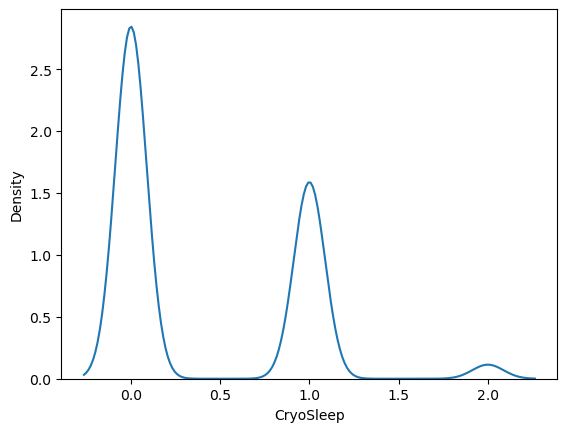

In [20]:
sns.kdeplot(data["CryoSleep"])


In [21]:
#Fill the Outliers with their mean value


In [22]:
for col in data.iloc[:,:-1].columns:
    if data.iloc[:,:-1][col].dtypes != 'object':
        q1 , q3 =data.iloc[:,:-1][col].quantile(0.25),data.iloc[:,:-1][col].quantile(0.75)
        iqr = q3 - q1
        ll = q1-1.5*iqr
        ul = q3 + 1.5*iqr
        data["Age"] = np.where(data["Age"]>ul,data["Age"].mean(),np.where(data["Age"]<ll,data["Age"].mean(),data["Age"]))  
        data["VIP"] = np.where(data["VIP"]>ul,data["VIP"].mean(),np.where(data["VIP"]<ll,data["VIP"].mean(),data["VIP"]))  
        data["RoomService"] = np.where(data["RoomService"]>ul,data["RoomService"].mean(),np.where(data["RoomService"]<ll,data["RoomService"].mean(),data["RoomService"]))
        data["Cabin"] = np.where(data["Cabin"]>ul,data["Cabin"].mean(),np.where(data["Cabin"]<ll,data["Cabin"].mean(),data["Cabin"]))  
        data["Spa"] = np.where(data["Spa"]>ul,data["Spa"].mean(),np.where(data["Spa"]<ll,data["Spa"].mean(),data["Spa"]))
        data["VRDeck"] = np.where(data["VRDeck"]>ul,data["VRDeck"].mean(),np.where(data["VRDeck"]<ll,data["VRDeck"].mean(),data["VRDeck"]))

In [23]:
#Find the Outliers Count


In [24]:
Q1=data.iloc[:,:-1].quantile(0.25)
Q3=data.iloc[:,:-1].quantile(0.75)
IQR=Q3-Q1
IQR
print("outlier Counter of the all features")
((data.iloc[:,:-1] < (Q1 - 1.5 * IQR)) | (data.iloc[:,:-1]> (Q3 + 1.5 * IQR))).sum()


outlier Counter of the all features


CryoSleep      0
Cabin          0
Age            0
VIP            0
RoomService    0
Spa            0
VRDeck         0
dtype: int64

In [25]:
x=data.iloc[:,:-1].values
y=data.iloc[:,-1].values


In [26]:
data['Transported'].value_counts()


True     4378
False    4315
Name: Transported, dtype: int64

In [27]:
#Balancing Technique


In [28]:
from imblearn.under_sampling import NearMiss
nm=NearMiss()
x_data,y_data=nm.fit_resample(x,y)

In [29]:
from collections import Counter
print(Counter(y_data))

Counter({False: 4315, True: 4315})


In [30]:
#Standerdisation (Feature Scaling)


In [31]:
from sklearn.preprocessing import StandardScaler
ssd=StandardScaler()
x_scaled=ssd.fit_transform(x_data)
x_scaled

array([[-7.39890343e-01, -2.15095497e-10,  3.73745479e-12, ...,
        -4.59010607e-12,  1.03739239e-11, -4.81747975e-12],
       [-7.39890343e-01, -2.15095497e-10,  3.73745479e-12, ...,
        -4.59010607e-12,  1.03739239e-11, -4.81747975e-12],
       [-7.39890343e-01, -2.15095497e-10,  3.73745479e-12, ...,
        -4.59010607e-12,  1.03739239e-11, -4.81747975e-12],
       ...,
       [ 1.12061480e+00, -2.15095497e-10,  3.73745479e-12, ...,
        -4.59010607e-12,  1.03739239e-11, -4.81747975e-12],
       [-7.39890343e-01, -2.15095497e-10,  3.73745479e-12, ...,
        -4.59010607e-12,  1.03739239e-11, -4.81747975e-12],
       [ 1.12061480e+00, -2.15095497e-10,  3.73745479e-12, ...,
        -4.59010607e-12,  1.03739239e-11, -4.81747975e-12]])

In [32]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y_data,test_size=0.2,random_state=20)

# Random Forest


In [33]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier()
rfc.fit(x_train,y_train)


RandomForestClassifier()

In [34]:
rfc_pred=rfc.predict(x_test)
rfc_pred

array([ True, False, False, ..., False,  True,  True])

In [35]:
from sklearn.metrics import accuracy_score,classification_report
accuracy_score(y_test,rfc_pred)*100

71.32097334878331

# Decision tree


In [36]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [37]:
dt_pred=dt.predict(x_test)
dt_pred

array([ True, False, False, ..., False,  True,  True])

In [38]:
accuracy_score(y_test,dt_pred)*100


71.84241019698725

# Naive bayes


In [39]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(x_train,y_train)

GaussianNB()

In [40]:
nb_pred=nb.predict(x_test)
nb_pred

array([ True, False, False, ..., False,  True,  True])

In [41]:
accuracy_score(y_test,nb_pred)*100


71.32097334878331

# Ensemble Technique


In [42]:
from sklearn.ensemble import VotingClassifier
vc=VotingClassifier(estimators=[("Random_Forest",rfc),("Decision_Tree",dt),("Naive_Bayes",nb)])
vc.fit(x_train,y_train)

VotingClassifier(estimators=[('Random_Forest', RandomForestClassifier()),
                             ('Decision_Tree', DecisionTreeClassifier()),
                             ('Naive_Bayes', GaussianNB())])

In [43]:
vc_pred=vc.predict(x_test)
vc_pred


array([ True, False, False, ..., False,  True,  True])

In [44]:
accuracy_score(y_test,vc_pred)*100


71.84241019698725

In [45]:
#Convert predicted values in dataframe
train_result=pd.DataFrame(np.c_[y_test,vc_pred],columns=["Actual","Transported"])
train_result

,Actual,Transported
0,True,True
1,True,False
2,False,False
3,False,False
4,True,True
...,...,...
1721,False,True
1722,False,False
1723,False,False
1724,False,True


In [46]:
train_result['Transported'].value_counts()


False    1151
True      575
Name: Transported, dtype: int64

In [47]:
test_data=test.iloc[:,[2,3,5,6,7,10,11]]
test_data

,CryoSleep,Cabin,Age,VIP,RoomService,Spa,VRDeck
0,True,G/3/S,27.0,False,0.0,0.0,0.0
1,False,F/4/S,19.0,False,0.0,2823.0,0.0
2,True,C/0/S,31.0,False,0.0,0.0,0.0
3,False,C/1/S,38.0,False,0.0,181.0,585.0
4,False,F/5/S,20.0,False,10.0,0.0,0.0
...,...,...,...,...,...,...,...
4272,True,G/1496/S,34.0,False,0.0,0.0,0.0
4273,False,NaN,42.0,False,0.0,10.0,144.0
4274,True,D/296/P,NaN,False,0.0,0.0,0.0
4275,False,D/297/P,NaN,False,0.0,0.0,523.0


In [48]:
test_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CryoSleep    4184 non-null   object 
 1   Cabin        4177 non-null   object 
 2   Age          4186 non-null   float64
 3   VIP          4184 non-null   object 
 4   RoomService  4195 non-null   float64
 5   Spa          4176 non-null   float64
 6   VRDeck       4197 non-null   float64
dtypes: float64(4), object(3)
memory usage: 234.0+ KB


In [49]:
from sklearn.preprocessing import LabelEncoder
l1=LabelEncoder()
test_data['CryoSleep']=l1.fit_transform(test_data['CryoSleep'])
test_data['Cabin']=l1.fit_transform(test_data['Cabin'])
test_data['VIP']=l1.fit_transform(test_data['VIP'])


In [50]:
test_data

,CryoSleep,Cabin,Age,VIP,RoomService,Spa,VRDeck
0,1,2784,27.0,0,0.0,0.0,0.0
1,0,1867,19.0,0,0.0,2823.0,0.0
2,1,257,31.0,0,0.0,0.0,0.0
3,0,259,38.0,0,0.0,181.0,585.0
4,0,1940,20.0,0,10.0,0.0,0.0
...,...,...,...,...,...,...,...
4272,1,2679,34.0,0,0.0,0.0,0.0
4273,0,3265,42.0,0,0.0,10.0,144.0
4274,1,602,NaN,0,0.0,0.0,0.0
4275,0,603,NaN,0,0.0,0.0,523.0


In [51]:
test_data['CryoSleep'].fillna(test_data['CryoSleep'].mean(),inplace=True)
test_data['Cabin'].fillna(test_data['Cabin'].mean(),inplace=True)
test_data['Age'].fillna(test_data['Age'].mean(),inplace=True)
test_data['VIP'].fillna(test_data['VIP'].mean(),inplace=True)
test_data['Spa'].fillna(test_data['Spa'].mean(),inplace=True)
test_data['VRDeck'].fillna(test_data['VRDeck'].mean(),inplace=True)
test_data['RoomService'].fillna(test_data['RoomService'].mean(),inplace=True)


In [52]:
test_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CryoSleep    4277 non-null   int64  
 1   Cabin        4277 non-null   int64  
 2   Age          4277 non-null   float64
 3   VIP          4277 non-null   int64  
 4   RoomService  4277 non-null   float64
 5   Spa          4277 non-null   float64
 6   VRDeck       4277 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 234.0 KB


<AxesSubplot:>

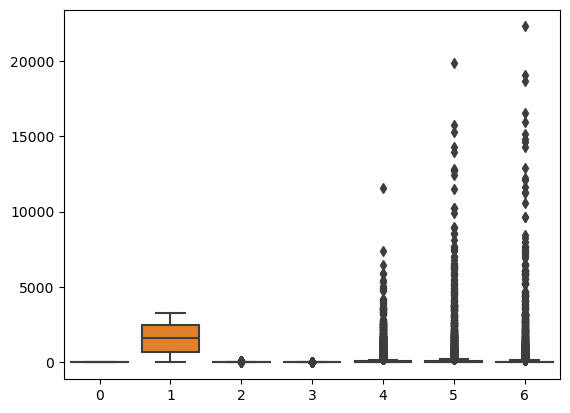

In [53]:
sns.boxplot(test_data.values)


In [54]:
#From above graph we say that outliers are present in given dataset


In [55]:
Q1=test_data.quantile(0.25)
Q3=test_data.quantile(0.75)
IQR=Q3-Q1
IQR
print("outlier Counter of the all features")
((test_data < (Q1 - 1.5 * IQR)) | (test_data> (Q3 + 1.5 * IQR))).sum()


outlier Counter of the all features


CryoSleep        0
Cabin            0
Age             75
VIP            167
RoomService    908
Spa            908
VRDeck         907
dtype: int64

In [56]:
#Now we fill the Outliers with their mean


In [57]:
for col in test_data.columns:
    if test_data[col].dtypes != 'object':
        q1 , q3 =test_data[col].quantile(0.25),test_data[col].quantile(0.75)
        iqr = q3 - q1
        ll = q1-1.5*iqr
        ul = q3 + 1.5*iqr
        test_data["Age"] = np.where(test_data["Age"]>ul,test_data["Age"].mean(),np.where(test_data["Age"]<ll,test_data["Age"].mean(),test_data["Age"]))  
        test_data["VIP"] = np.where(test_data["VIP"]>ul,test_data["VIP"].mean(),np.where(test_data["VIP"]<ll,test_data["VIP"].mean(),test_data["VIP"]))  
        test_data["RoomService"] = np.where(test_data["RoomService"]>ul,test_data["RoomService"].mean(),np.where(test_data["RoomService"]<ll,test_data["RoomService"].mean(),test_data["RoomService"]))
        test_data["Cabin"] = np.where(test_data["Cabin"]>ul,test_data["Cabin"].mean(),np.where(test_data["Cabin"]<ll,test_data["Cabin"].mean(),test_data["Cabin"]))  
        test_data["Spa"] = np.where(test_data["Spa"]>ul,test_data["Spa"].mean(),np.where(test_data["Spa"]<ll,test_data["Spa"].mean(),test_data["Spa"]))
        test_data["VRDeck"] = np.where(test_data["VRDeck"]>ul,test_data["VRDeck"].mean(),np.where(test_data["VRDeck"]<ll,test_data["VRDeck"].mean(),test_data["VRDeck"]))

In [58]:
#Now we Count the Count of Outliers


In [59]:
Q1=test_data.quantile(0.25)
Q3=test_data.quantile(0.75)
IQR=Q3-Q1
IQR
print("outlier Counter of the all features")
((test_data < (Q1 - 1.5 * IQR)) | (test_data> (Q3 + 1.5 * IQR))).sum()


outlier Counter of the all features


CryoSleep      0
Cabin          0
Age            0
VIP            0
RoomService    0
Spa            0
VRDeck         0
dtype: int64

<AxesSubplot:>

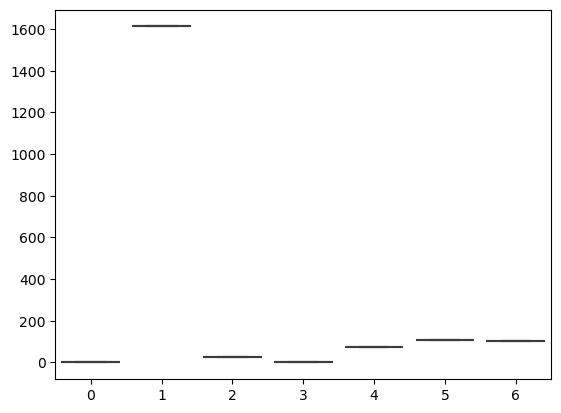

In [60]:
sns.boxplot(test_data.values)


In [61]:
from sklearn.preprocessing import StandardScaler
ssd=StandardScaler()
test_scaled=ssd.fit_transform(test_data)
test_scaled


array([[ 1.11673669,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.75852158,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 1.11673669,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.11673669,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.75852158,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 1.11673669,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

<AxesSubplot:>

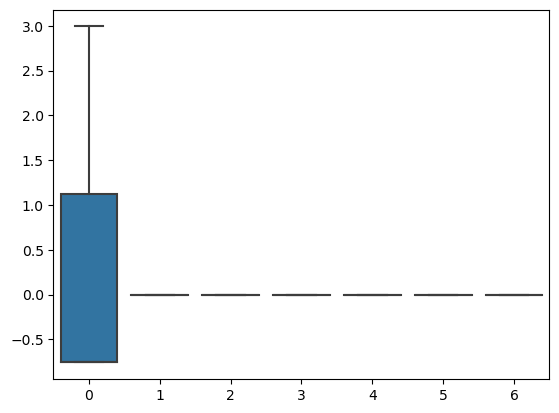

In [62]:
sns.boxplot(test_scaled)


In [63]:
vc_pred_test=vc.predict(test_scaled)
vc_pred_test


array([ True, False,  True, ...,  True, False,  True])

In [64]:
#Convert predicted values in dataframe
test_result=pd.DataFrame(np.c_[test['PassengerId'],vc_pred_test],columns=["PassengerId","Transported"])
test_result.head()


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,False
4,0023_01,False


In [65]:
test_result['Transported'].unique()


array([True, False], dtype=object)

In [66]:
test_result['Transported'].value_counts()


False    2733
True     1544
Name: Transported, dtype: int64

In [67]:
test_result.to_csv("Titanic Spaceship competition Submission.csv")
